## Artificial Intelligence and Deep Learning
## Programming Project 2 - **Using Machine Learning to Investigate Biscuit Dunking Data**


Elliot Ayliffe  |  2046374

In [1]:
# Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Import the module containing the required functions
from biscuit_dunking_functions import (
    preprocessing,
    train_random_forest_model,
    train_SVM_model,
    train_MLP_classifier, 
    classifier_evaluation,
    regressor_evaluation,
    heatmap_classifier_accuracies,
    plot_permutation_importance,
    boxplots,
    histogram,
    plot_wb_rf_comparison,
    washburn_L,
    washburn_r
)

<div style="color:purple">

### **Task 1.** 

### **Comparing Three Machine Learning Algorithms for Biscuit Classification:**

**Research Questions:**

- Can a machine learning algorithm be used to identify the different types of biscuits?
- Can we optimise the models to improve classification performance? (accuracy, F1 score etc...)
- Which ML model is best for this task?
- Can we identify which features are most important when predicting biscuit type?

**Analysis Steps:**

1. Preprocessing of the dunking-data set.
1. Training and evaluation of 3 different classifiers:  

    - **Random Forest Classifier**
    - **Support Vector Classifier (SVC)**
    - **Multi-layer Perceptron Classifer (MLP)**

1. Optimise the models by hyperparameter tuning using GridSearchCV and visualise the improvement.
1. Assess the feature importance using permutation importance for all 3 models.

In [2]:
# Load the training dataset (dunking-data)
dunking_df = pd.read_csv("dunking-data.csv")
dunking_df

,gamma,phi,eta,L,t,biscuit
0,0.073897,1.333006,0.000999,0.011196,19.362214,Digestive
1,0.080946,1.476758,0.001012,0.005894,11.852589,Digestive
2,0.087408,1.477141,0.000984,0.009249,24.793669,Digestive
3,0.070793,1.502001,0.001002,0.003774,16.292780,Hobnob
4,0.058917,1.548274,0.001004,0.002291,13.662271,Hobnob
...,...,...,...,...,...,...
2995,0.084596,1.557367,0.000981,0.003221,24.231107,Digestive
2996,0.067928,1.487239,0.000993,0.003933,12.256570,Hobnob
2997,0.059526,1.444489,0.000998,0.007583,26.464108,Hobnob
2998,0.071386,1.212213,0.001004,0.013988,22.772293,Digestive


In [3]:
# View the initial statistics for the absorption length 'L', grouped by each biscuit type 
L_stats = dunking_df.groupby('biscuit')[["L"]].describe()
print("\nSummary statistics by biscuit type for absorption length (L):\n")
L_stats


Summary statistics by biscuit type for absorption length (L):



L                                                              \
            count      mean       std       min       25%       50%       75%   
biscuit                                                                         
Digestive  1000.0  0.007864  0.003604  0.000329  0.005221  0.007630  0.010143   
Hobnob     1000.0  0.006022  0.002861  0.000185  0.003891  0.005763  0.007842   
Rich Tea   1000.0  0.004843  0.002150  0.000392  0.003306  0.004721  0.006188   

                     
                max  
biscuit              
Digestive  0.019230  
Hobnob     0.015657  
Rich Tea   0.011808

**1. Data Preprocessing for dunking-data:**

In [4]:
# Checking for missing values in the entire dataset 
missing_values = dunking_df.isnull().sum()
print(missing_values)

# There are no missing values

gamma      0
phi        0
eta        0
L          0
t          0
biscuit    0
dtype: int64


In [5]:
# Separate the features from the target variable
X = dunking_df.drop(columns=['biscuit'])
y = dunking_df['biscuit']

# Preprocess the data (split train-test and scale)
X_train, X_test, y_train, y_test = preprocessing(X, y, test_size=0.2, stratify=True, scaling=True)
print(f"X shape: {X_train.shape, X_test.shape}")
print(f"y shape: {y_train.shape, y_test.shape}")

X shape: ((2400, 5), (600, 5))
y shape: ((2400,), (600,))


**2. Training and comparing the performance of 3 classification algorithms:**


Random Forest Classifier

In [6]:
# Train the Random Forest Classifier 
trained_rf_classifier = train_random_forest_model(X_train, y_train, task='classification', optimise_model=False)      # No hyperparameter tuning 

# Evaluate the classification performance (make predictions and compute evaluation metrics)
rf_clf_test_accuracy = classifier_evaluation(trained_rf_classifier, X_train, X_test, y_train, y_test, "Random Forest Classifier")


Evaluation Metrics for Random Forest Classifier:

Accuracy on the training data: 100.0% 
Accuracy on the testing data: 81.3% 
              precision    recall  f1-score   support

   Digestive       0.86      0.86      0.86       200
      Hobnob       0.73      0.71      0.72       200
    Rich Tea       0.85      0.86      0.86       200

    accuracy                           0.81       600
   macro avg       0.81      0.81      0.81       600
weighted avg       0.81      0.81      0.81       600



Support Vector Classifier (SVC)

In [7]:
# Train the SVC 
trained_svc = train_SVM_model(X_train, y_train, task='classification', optimise_model=False)      # No hyperparameter tuning 

# Evaluate the classification performance (make predictions and compute evaluation metrics)
svc_test_accuracy = classifier_evaluation(trained_svc, X_train, X_test, y_train, y_test, "SVC")


Evaluation Metrics for SVC:

Accuracy on the training data: 88.2% 
Accuracy on the testing data: 86.8% 
              precision    recall  f1-score   support

   Digestive       0.93      0.90      0.92       200
      Hobnob       0.82      0.78      0.80       200
    Rich Tea       0.85      0.93      0.89       200

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600



Multi-layer Perceptron (MLP) Classifier (Neural Network)

In [8]:
# Train the MLP Classifier
trained_mlp_classifier = train_MLP_classifier(X_train, y_train, optimise_model=False)      # No hyperparameter tuning 

# Evaluate the classification performance (make predictions and compute evaluation metrics)
mlp_clf_test_accuracy = classifier_evaluation(trained_mlp_classifier, X_train, X_test, y_train, y_test, "MLP Classifier")


Evaluation Metrics for MLP Classifier:

Accuracy on the training data: 94.4% 
Accuracy on the testing data: 93.8% 
              precision    recall  f1-score   support

   Digestive       0.98      0.99      0.98       200
      Hobnob       0.92      0.90      0.91       200
    Rich Tea       0.92      0.93      0.92       200

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



**3. Model Optimisation**

- Attempting to improve classification performance through hyperparameter tuning using GridSearchCV
- Retraining each model with optimise_model=True. GridSearchCV finds the hyperparameter combination that achieves the highest possible accuracy.
- Each grid search may take up to 30 seconds to run 

In [9]:
# Retrain the Random Forest Classifier with optimise_model=True
trained_rf_clf_optimised = train_random_forest_model(X_train, y_train, task='classification', optimise_model=True)        

# Display new performance metrics
rf_clf_opt_test_accuracy = classifier_evaluation(trained_rf_clf_optimised, X_train, X_test, y_train, y_test, "Random Forest Classifier")

Fitting 5 folds for each of 81 candidates, totalling 405 fits


Optimal parameters found: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score: 0.80

Evaluation Metrics for Random Forest Classifier:

Accuracy on the training data: 99.9% 
Accuracy on the testing data: 82.5% 
              precision    recall  f1-score   support

   Digestive       0.86      0.85      0.85       200
      Hobnob       0.74      0.73      0.74       200
    Rich Tea       0.87      0.90      0.88       200

    accuracy                           0.82       600
   macro avg       0.82      0.83      0.82       600
weighted avg       0.82      0.82      0.82       600



In [10]:
# Retrain the SVC with optimise_model=True 
trained_svc_optimised = train_SVM_model(X_train, y_train, task='classification', optimise_model=True)

# Display new performance metrics
svc_opt_test_accuracy = classifier_evaluation(trained_svc_optimised, X_train, X_test, y_train, y_test, "SVC")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Optimal parameters found: {'C': 100, 'coef0': 1.0, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validation score: 0.92

Evaluation Metrics for SVC:

Accuracy on the training data: 94.7% 
Accuracy on the testing data: 93.0% 
              precision    recall  f1-score   support

   Digestive       0.96      0.98      0.97       200
      Hobnob       0.92      0.89      0.90       200
    Rich Tea       0.92      0.93      0.92       200

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600



In [11]:
# Retrain the MLP classifier with optimise_model=True
trained_mlp_clf_optimised = train_MLP_classifier(X_train, y_train, optimise_model=True) 

# Display new performance metrics
mlp_clf_opt_test_accuracy = classifier_evaluation(trained_mlp_clf_optimised, X_train, X_test, y_train, y_test, "MLP Classifier")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Optimal parameters found: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'constant'}
Best cross-validation score: 0.92

Evaluation Metrics for MLP Classifier:

Accuracy on the training data: 94.0% 
Accuracy on the testing data: 93.7% 
              precision    recall  f1-score   support

   Digestive       0.97      0.98      0.98       200
      Hobnob       0.93      0.88      0.90       200
    Rich Tea       0.91      0.95      0.93       200

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



**4. Compare Classification Model Performance**

- Visualise the improvements from hyperparameter tuning (non-optimised vs optimised)

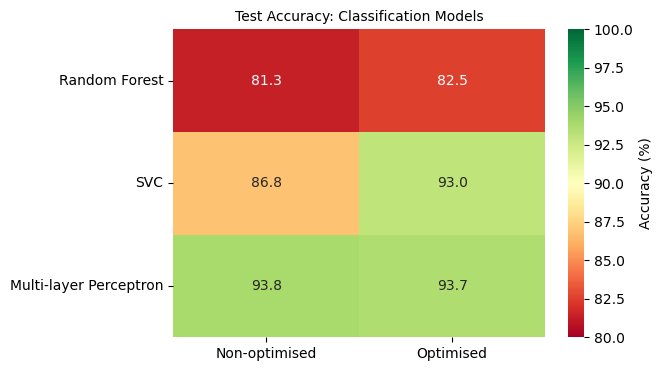

In [12]:
# Combine the test accuracies into a dictionary 
classifier_accuracies = {
    'Random Forest': [rf_clf_test_accuracy, rf_clf_opt_test_accuracy],
    'SVC': [svc_test_accuracy, svc_opt_test_accuracy],
    'Multi-layer Perceptron': [mlp_clf_test_accuracy, mlp_clf_opt_test_accuracy]
}

# plot heatmap to visually compare model performance 
heatmap_classifier_accuracies(classifier_accuracies)

**5. Assessing Feature Importance using Permutation Importance**
- Permuation importance measures the reduction in model performance when a feature is randomly shuffled.
- For example, a large decrease in performance (accuracy) when a feature is shuffled indicates a high importance of that feature for predictions. If the performance does not decrease, the feature has low importance.
- This is used, rather than impurity-based importance, as it can can be applied to all models (it is model-agnostic).

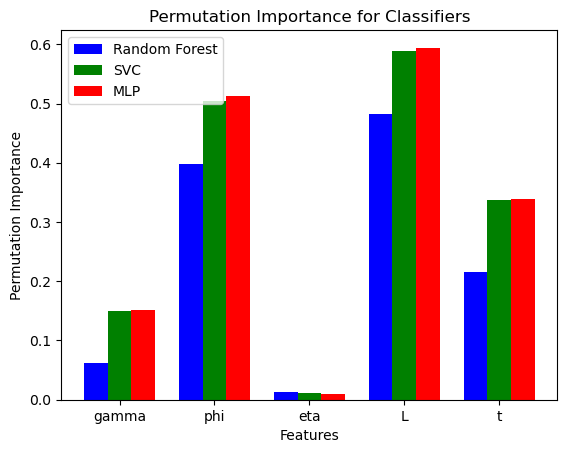

In [13]:
# Plot permutation importance
plot_permutation_importance(X, X_test, y_test, trained_rf_clf_optimised, trained_svc_optimised, trained_mlp_classifier)

Attempting to increase SVC model performance by removing the tea dynamic viscosity feature (eta) due to its small permutation importance. 

In [14]:
# Remove the tea dynamic viscosity feature (3rd column, index 2) from training and test data
# Retraining the SVC model without it may improve performance due to its substantially smaller permutation importance
X_train_no_eta = np.delete(X_train, 2, axis=1)
X_test_no_eta= np.delete(X_test, 2, axis=1)

# Retrain the SVC with optimise_model=True 
svc_no_eta = train_SVM_model(X_train_no_eta, y_train,task='classification', optimise_model=True)

# Display performance metrics
svc_test_accuracy_no_eta = classifier_evaluation(svc_no_eta, X_train_no_eta, X_test_no_eta, y_train, y_test, "SVC")


Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Optimal parameters found: {'C': 100, 'coef0': 0.5, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validation score: 0.93

Evaluation Metrics for SVC:

Accuracy on the training data: 95.0% 
Accuracy on the testing data: 92.3% 
              precision    recall  f1-score   support

   Digestive       0.96      0.99      0.98       200
      Hobnob       0.90      0.87      0.88       200
    Rich Tea       0.91      0.91      0.91       200

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600



<div style="color:purple">

### **Task 1 Findings:**

- All classifiers are relatively **successful in identifying biscuit type** when trained on the dunking-data set.

- SVC had the biggest improvement through hyperparameter tuning (from a test accuracy of **86.8% to 93.0%**)

- Interestingly, the non-optimised MLP performed the best (**93.8%** test accuracy)

- **Digestives** were classified more easily than Hobnobs or Rich Teas (higher F1-scores, precision and recall)

- All classifiers show an equal order of feature importance (permutation importance)

- **Absorption length 'L'** and **contact angle 'phi'** were most important for classifying biscuit type, whereas tea dynamic viscosity 'eta' was least important (it had little effect on performance when shuffled)

- Removing the unimportant 'eta' feature from the training data made no improvement on SVC model performance. It actually made it slightly worse (**93.0% to 92.5%**).

<div style="color:purple">

### **Task 2.** 

### **Analysing the Difference in Pore Radius across Biscuit Types:**

**Research Questions:**

- Is their a significant difference in pore radius between the three biscuit types?
- How can we identify the biscuits in the pore dataset? (microscopy-data)

**Analysis Steps"**

1. Merge the dunking-data set with the microscopy-data set on the common parameters (e.g. 'gamma', 'phi' etc..) to identify the biscuit type for each sample.

    - This is valid as the microscopy dataset is a subset (one-sixth) of dunking-data, and is the same samples with added pore radius.

1. Compute the statistics (mean, standard deviation, etc...) for the pore radius for each biscuit type.

1. Visualise and compare the difference using a boxplot and histogram.


In [15]:
# Load the pore dataset (microscopy-data.csv)
pore_radius_df = pd.read_csv("microscopy-data.csv")
pore_radius_df

# This is a subset (1/6) of the dunking-data set with added pore radius (r) but without the biscuit label 

,gamma,phi,eta,L,t,r
0,0.084596,1.557367,0.000981,0.003221,24.231107,7.453712e-07
1,0.064291,1.538842,0.000998,0.002395,22.169765,2.600680e-07
2,0.086224,1.546138,0.001008,0.003036,23.257709,3.734618e-07
3,0.082859,1.566878,0.000997,0.001261,12.717432,7.567173e-07
4,0.090832,1.570229,0.001002,0.000576,15.189146,8.239067e-07
...,...,...,...,...,...,...
495,0.077699,1.481847,0.000989,0.006078,21.967531,4.751893e-07
496,0.067776,1.488293,0.001011,0.006595,18.163634,8.798032e-07
497,0.074166,1.554817,0.000997,0.003041,18.000978,8.652230e-07
498,0.081415,1.439910,0.001011,0.009119,19.136713,8.128785e-07


As the microscopy-data is a subset (1/6) of the dunking-data, we can merge them on the common columns (e.g. 'gamma', 'phi' etc...) to identify the biscuit type for each sample.

In [16]:
# Merge the microscopy-data and dunking-data on the shared features to identify the biscuit type
labelled_pore_df = pore_radius_df.merge(dunking_df, on=['gamma', 'phi', 'eta', 'L', 't'], how='left')
labelled_pore_df

,gamma,phi,eta,L,t,r,biscuit
0,0.084596,1.557367,0.000981,0.003221,24.231107,7.453712e-07,Digestive
1,0.064291,1.538842,0.000998,0.002395,22.169765,2.600680e-07,Rich Tea
2,0.086224,1.546138,0.001008,0.003036,23.257709,3.734618e-07,Hobnob
3,0.082859,1.566878,0.000997,0.001261,12.717432,7.567173e-07,Digestive
4,0.090832,1.570229,0.001002,0.000576,15.189146,8.239067e-07,Digestive
...,...,...,...,...,...,...,...
495,0.077699,1.481847,0.000989,0.006078,21.967531,4.751893e-07,Hobnob
496,0.067776,1.488293,0.001011,0.006595,18.163634,8.798032e-07,Digestive
497,0.074166,1.554817,0.000997,0.003041,18.000978,8.652230e-07,Digestive
498,0.081415,1.439910,0.001011,0.009119,19.136713,8.128785e-07,Digestive


In [17]:
# Calculate statistics (mean, standard deviation, etc..) for the pore radii for each biscuit type using pandas agg() function 
pore_statistics = labelled_pore_df.groupby('biscuit')['r'].agg(
    Count='count',
    Mean='mean',
    Standard_Deviation = 'std',
    Min='min',
    Median='median',
    Max='max'
)

# Display stats table 
pore_statistics

,Count,Mean,Standard_Deviation,Min,Median,Max
biscuit,,,,,,
Digestive,168,8.034292e-07,5.817930e-08,7.004029e-07,8.077031e-07,8.991764e-07
Hobnob,163,4.963689e-07,8.027767e-08,2.324710e-07,4.939518e-07,7.334682e-07
Rich Tea,169,3.038971e-07,4.716600e-08,1.562959e-07,3.092374e-07,4.297787e-07


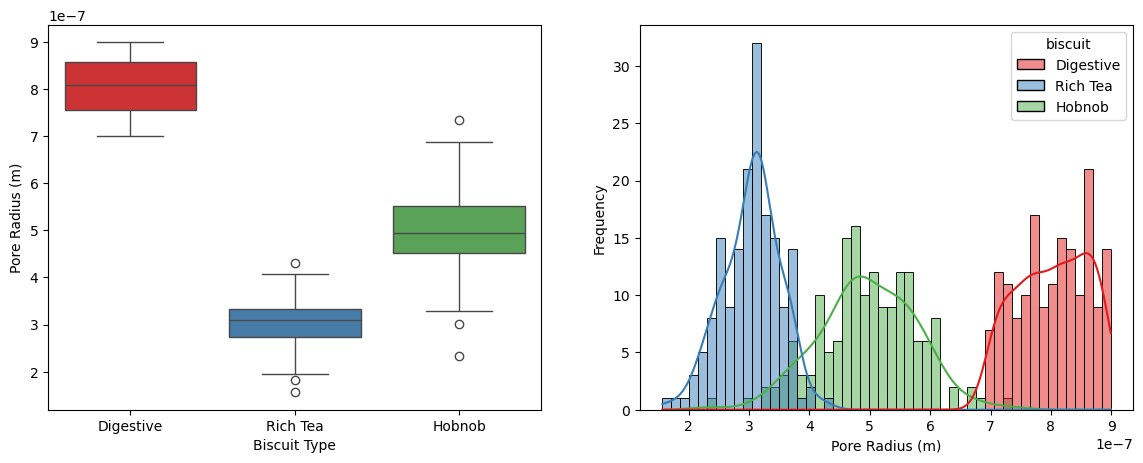

In [18]:
# Visualise the difference in pore radius with biscuit type via a boxplot and histogram 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

boxplots(labelled_pore_df, 'biscuit', 'r', ax[0])      # plot boxplot
histogram(labelled_pore_df, 'biscuit', 'r', ax[1])     # plot histogram

<div style="color:purple">

### **Task 2 Findings:**

- There is a fairly equal count of each biscuit type in the microscopy-data set (ranging from 163 to 169).

- Each biscuit type has a clear distinct range of pore radii (evidenced by the 3 spikes of the histogram)

- Digestives have the highest mean pore radius, followed by Hobnobs, then Rich Tea.

- Hobnobs had the highest standard deviation (spread) indicating greater variability, whereas Rich Tea had the smallest SD indicating less variation in pore size.

<div style="color:purple">

### **Task 3.**

### **Evaluating the Performance of the Physics-based Washburn Equation vs. ML Regression**

**Research Questions:**

- Can a machine learning regressor perform better than the Washburn equation when predicting continuous variables?
- How accurate is the Washburn equation for biscuit dunking analysis?
- Which ML regressor performs best, Random Forest or Support Vector Regressor (SVR)?

**Washburn Equation:**

Calculating Absorption Length (L):

$$
L = \sqrt{\frac{\gamma r t \cos(\phi)}{2 \eta}}
$$

where:

- $ \gamma $ = surface tension of the liquid  (Nm-1)
- $ r $  = pore radius (m)
- $ t $ = time (s) 
- $\phi$ = contact angle (rad)
- $\eta$ = viscosity  (Pas)

This can be rearranged to find pore radius (r):

$$
r = \frac{2 \eta L^2}{\gamma t \cos(\phi)}
$$


**Analysis Steps:**

1. Preprocess the data 

1. Train two ML regressors (Random Forest and SVR) on the microscopy-data set and evaluate their performance when predicting the absorption length 'L'.

1. Compare the performances using Root Mean Squared Error (RMSE) and R-Squared metrics:

    - **RMSE** measures the average error between predicted and actual values (same units as the target variable). **Lower RMSE = Better model predictions**
    - **R-Squared** measures the proportion of the variance in the target variable that is explained by the model (i.e how well the model predicts the target values). **$R^{2} = 1$ means the model perfectly predicts the target value explaining 100% of the variance**, $R^{2} = 0$ means the model performs no better than the mean of target variable, and a negative value means the model is worse than a predicting the mean. 

1. Compare the performance of the best ML regressor vs. the Washburn equation when predicting both:

    - **Absorption Length 'L'**
    - **Pore Radius 'r'**

1. Visualising the results for both parameters using scatterplots and histograms.


#### **1. Comparing the performance of two ML regressors:** Random Forest vs. Support Vector Regressor (SVR)

In [19]:
# Separate the features from the target variable
Xl = labelled_pore_df.drop(columns=['biscuit', 'L']) # Drop the biscuit type feature so that it is a fair comparison to the Washburn equation (also drop 'L')
yl = labelled_pore_df['L']                           # set target to L (continuous)

# Preprocess the data (split train-test and scale)
Xl_train, Xl_test, yl_train, yl_test = preprocessing(Xl, yl, test_size=0.2, stratify=False, scaling=True)       # set stratify to false as it is not needed for regression
print(f"X shape: {Xl_train.shape, Xl_test.shape}")
print(f"y shape: {yl_train.shape, yl_test.shape}")

X shape: ((400, 5), (100, 5))
y shape: ((400,), (100,))


In [20]:
# Train Random Forest Regressor (with hyperparameter tuning)
trained_rf_reg = train_random_forest_model(Xl_train, yl_train, task='regression', optimise_model=True)      # set task to regression 

# Display performance metrics
rf_reg_rmse, rf_reg_r2, rf_pred_L = regressor_evaluation(trained_rf_reg, Xl_train, Xl_test, yl_train, yl_test, "Random Forest Regressor")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Optimal parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score: -0.00

Evaluation Metrics for Random Forest Regressor:

RMSE on the training data: 2.46e-04
R² on the training data: 0.9943

RMSE on the testing data: 4.98e-04
R² on the testing data: 0.9686


In [21]:
# Train SVR (with hyperparameter tuning)
trained_svr = train_SVM_model(Xl_train, yl_train, task='regression', optimise_model=True)              # Set task to regression

# Display performance metrics
svr_rmse, svr_r2, svr_pred_L = regressor_evaluation(trained_svr, Xl_train, Xl_test, yl_train, yl_test, "Support Vector Regressor (SVR)")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Optimal parameters found: {'C': 0.1, 'coef0': 0.0, 'degree': 3, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation score: -0.00

Evaluation Metrics for Support Vector Regressor (SVR):

RMSE on the training data: 4.86e-03
R² on the training data: -1.2225

RMSE on the testing data: 4.86e-03
R² on the testing data: -1.9953


In contrast to the classification models, the Random Forest performs much better than the SVM regressor evidenced by its lower RMSE and higher R-squared value (0.97) for the testing data.
The random forest makes highly accurate predictions, explaining 97% of the variance in the target variable.

#### **2. Comparing the performance of the Random Forest regressor vs. Washburn Equation**

**Predicting Absorption Length 'L'**:

In [22]:
# Using the Washburn equation, make predictions for 'L' using the test data to allow comparison with the RF regressor
washburn_L_pred = washburn_L(Xl.loc[yl_test.index.tolist()])

# Calculate RMSE and R-squared score 
rmse_washburn_L = np.sqrt(mean_squared_error(yl_test, washburn_L_pred))
r2_washburn_L = r2_score(yl_test, washburn_L_pred)

In [23]:
# Print the evaluation metrics, comparing the performance of RF and Washburn equation when predicting 'L'
print(f"\033[1mPredicting L\033[0m \n")
print(f"Random Forest Regressor:")
print(f"RMSE: {rf_reg_rmse:.2e}")
print(f"R-squared: {rf_reg_r2:.4f}\n")
print(f"Washburn Equation:")
print(f"RMSE: {rmse_washburn_L:.2e}")
print(f"R-squared: {r2_washburn_L:.4f}")

Predicting L 

Random Forest Regressor:
RMSE: 4.98e-04
R-squared: 0.9686

Washburn Equation:
RMSE: 6.84e-05
R-squared: 0.9994


**Predicting Pore Radius 'r'**:

In [24]:
# Separate the features from the target variable
Xr = labelled_pore_df.drop(columns=['biscuit', 'r']) # Drop the biscuit type feature so that it is a fair comparison to the Washburn equation (also drop pore radius r)
yr = labelled_pore_df['r']                           # set target to pore radius (continuous)

# Preprocess the data (split train-test and scale)
Xr_train, Xr_test, yr_train, yr_test = preprocessing(Xr, yr, test_size=0.2, stratify=False, scaling=True)       # set stratify to false as it is not needed for regression

In [25]:
# Train Random Forest Regressor
trained_rf_reg = train_random_forest_model(Xr_train, yr_train, task='regression', optimise_model=False)      # set task to regression 

# Display performance metrics
rf_reg_rmse_r, rf_reg_r2_r, rf_pred_r = regressor_evaluation(trained_rf_reg, Xr_train, Xr_test, yr_train, yr_test, "Random Forest Regressor")


Evaluation Metrics for Random Forest Regressor:

RMSE on the training data: 4.51e-08
R² on the training data: 0.9568

RMSE on the testing data: 1.15e-07
R² on the testing data: 0.7124


In [26]:
# Using the Washburn equation, make predictions for 'r' using the same test data to allow comparison with the RF regressor
washburn_r_pred = washburn_r(Xr.loc[yr_test.index.tolist()])

# Calculate RMSE and R-squared score 
rmse_washburn_r = np.sqrt(mean_squared_error(yr_test, washburn_r_pred))
r2_washburn_r = r2_score(yr_test, washburn_r_pred)

In [27]:
# Print the evaluation metrics, comparing the performance of RF and Washburn equation when predicting 'r'
print(f"\033[1mPredicting r\033[0m \n")
print(f"Random Forest Regressor:")
print(f"RMSE: {rf_reg_rmse_r:.2e}")
print(f"R-squared: {rf_reg_r2_r:.4f}\n")
print(f"Washburn Equation:")
print(f"RMSE: {rmse_washburn_r:.2e}")
print(f"R-squared: {r2_washburn_r:.4f}")

Predicting r 

Random Forest Regressor:
RMSE: 1.15e-07
R-squared: 0.7124

Washburn Equation:
RMSE: 1.19e-08
R-squared: 0.9969


#### **3. Plotting Findings for Visual Comparison**

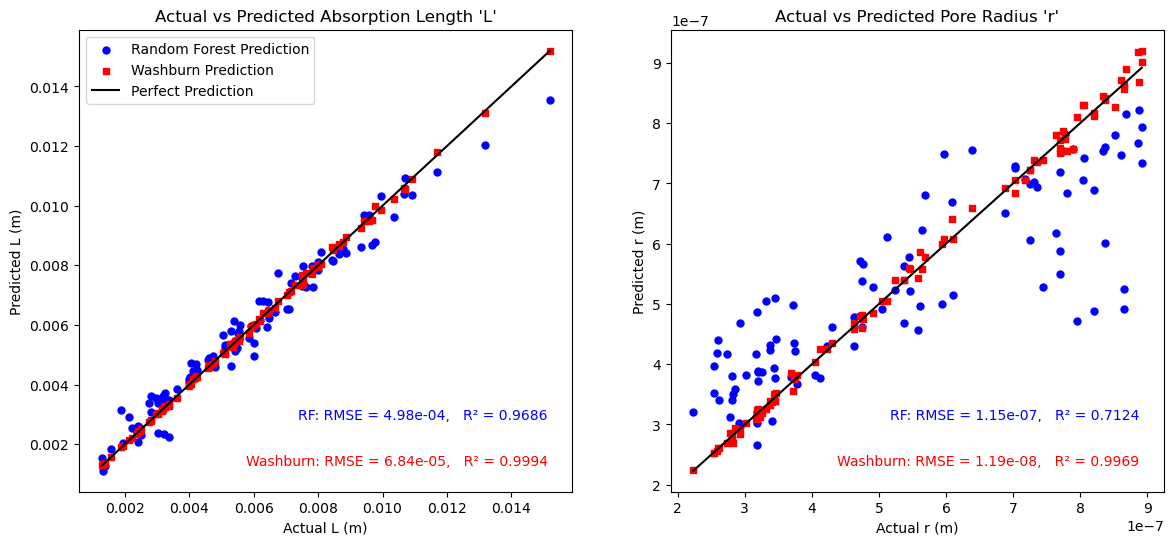

In [28]:
# Store all the metrics (RMSE and R-squared scores) in a list 
metrics = [rf_reg_rmse, rf_reg_r2, rmse_washburn_L, r2_washburn_L, rf_reg_rmse_r, rf_reg_r2_r, rmse_washburn_r, r2_washburn_r]

# Plot scatter plots to compare how well the random forest regressor and the washburn equation predict continuous parameters 
plot_wb_rf_comparison(yl_test, yr_test, rf_pred_L, washburn_L_pred, rf_pred_r, washburn_r_pred, metrics)

# A tighter fit to the black line indicates better performance

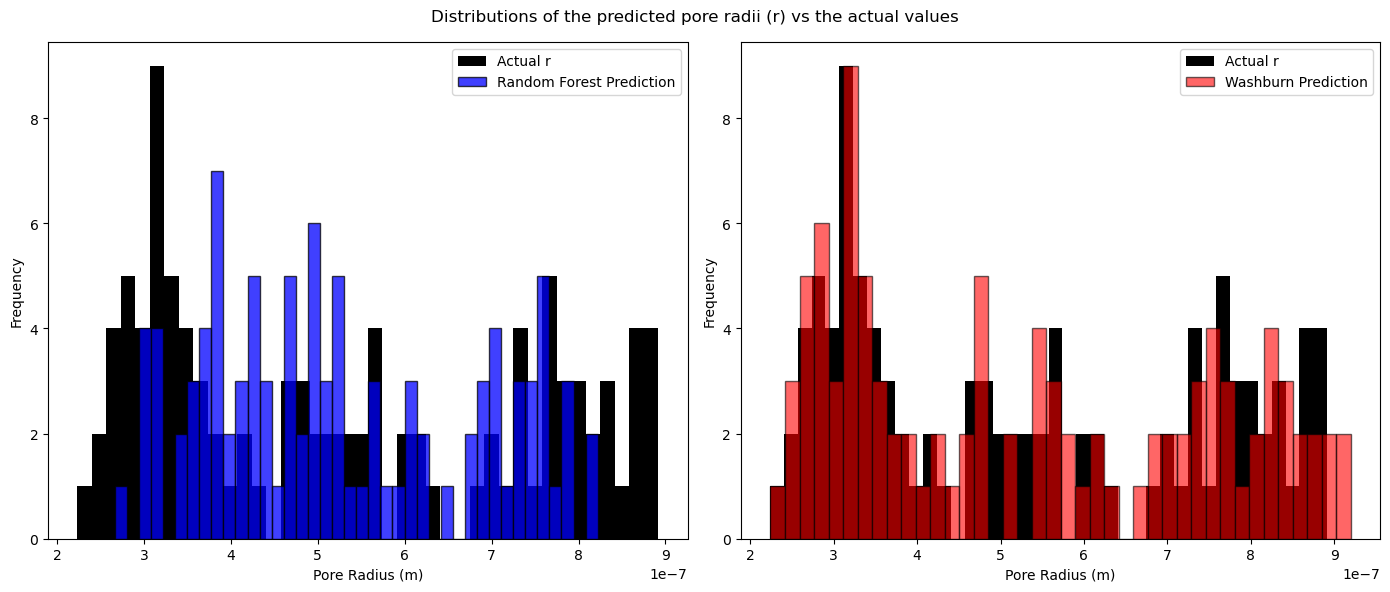

In [29]:
# Plot overlayed histograms of the 'r' predictions to see if they identified the three clear biscuit types shown in the histogram above in RQ 2
fig, ax = plt.subplots(1,2, figsize=(14,6))

# plot the actual pore radius values 
for a in ax:
    a.hist(yr_test, bins=40, color='black', label='Actual r')
    a.set_xlabel('Pore Radius (m)')
    a.set_ylabel('Frequency')

# plot the RF and Washburn predictions
ax[0].hist(rf_pred_r, bins=40, color='blue', label='Random Forest Prediction', alpha=0.75, edgecolor='black')
ax[1].hist(washburn_r_pred, bins=40, color='red', label='Washburn Prediction', alpha=0.6, edgecolor='black')
ax[0].legend()
ax[1].legend()
fig.suptitle("Distributions of the predicted pore radii (r) vs the actual values", fontsize=12)
plt.tight_layout()
plt.show()

<div style="color:purple">

### **Task 3 Findings:**

- Random Forest regressor performs much better the SVR, achieving much lower RMSE and higher R-squared scores. 

- Random Forest performs well when predicting absorption length 'L' ($R^{2}$ = 0.97 for test data)

- Random Forest does not perform very well when predicting pore radius 'r' ($R^{2}$ = 0.71 for test data) shown by the variation from the perfect prediction line (black) in the scatter plot.

- The Washburn equation outperforms the Random Forest regressor when predicting both absorption length and pore radius with lower RMSE scores and higher $R^{2}$ scores all round.

- The Washburn equation manages to successfully predict the 3 histogram spikes representing the biscuits pore radii ($R^{2}$ = 0.997), whereas the Random Forest does not capture this pattern.

- Overall the Washburn equation is highly accurate for estimating continuous variables within this biscuit dunking analysis. An ML regressor was not able to match this accuracy.

<div style="color:purple">

### **Task 4.** 

### **Enhancing Classification Model Performance by Incorporating an Additional Physics-derived Feature:**

**Research Questions:**

- Can we use the trained classification model to successfully predict which biscuit type was used for each time-resolved dataset (tr-1, tr-2, tr-3)?

- Can we increase the accuracy of the classification model by including a Washburn-calculated parameter to the training dataset?

- How does this change the feature importance scores?
 
**Analysis Steps:**

1. Explore the 3 time-resolved datasets (tr-1, tr-2, tr-3), looking for distinct patterns between the datasets.

1. Predict the biscuit type for each of these datasets using the SVC model trained in Task 1.

1. Calculate the pore radius for each sample in the dunking-data set using the Washburn equation (justified by its high accuracy shown in Task 3).

1. Include this pore radius as an additional feature and retrain the classifier.

1. Evaluate any improvements in accuracy and investigate how the permutation importance has changed.

**1. Investigating the Time-Resolved Datasets:** Can we predict which biscuit type was used for each dataset?

- Each dataset includes time-resolved L measurements for a single biscuit type (but we don't know which is which)

In [30]:
# Load in the time-resolved data 
tr_biscuit_1 = pd.read_csv("tr-1.csv")
tr_biscuit_2 = pd.read_csv("tr-2.csv")
tr_biscuit_3 = pd.read_csv("tr-3.csv")

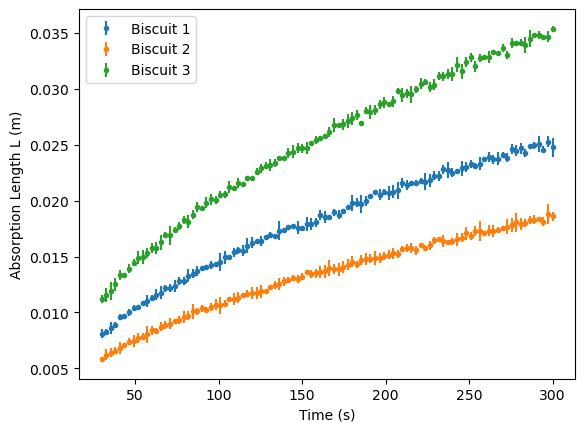

In [31]:
# Plot the datasets on the same graph to visualise any distinct patterns
fig, ax = plt.subplots()
ax.errorbar(tr_biscuit_1['t'], tr_biscuit_1['L'], yerr=tr_biscuit_1['dL'], fmt='o', ms=3, label="Biscuit 1")
ax.errorbar(tr_biscuit_2['t'], tr_biscuit_2['L'], yerr=tr_biscuit_2['dL'], fmt='o',ms=3, label="Biscuit 2")
ax.errorbar(tr_biscuit_3['t'], tr_biscuit_3['L'], yerr=tr_biscuit_3['dL'], fmt='o', ms=3, label="Biscuit 3")

# Format plot 
ax.set_xlabel("Time (s)")
ax.set_ylabel("Absorption Length L (m)")
ax.legend()
plt.show()

Each biscuit type exhibits a clear difference in absorption length with time. Can we use the classification model trained earlier to predict which biscuit type is which. If it is successful, there should be no crossover between biscuit types with the tr datasets.

In [32]:
# Combine all the biscuits into one DataFrame
all_tr_biscuits = pd.concat([tr_biscuit_1, tr_biscuit_2, tr_biscuit_3], ignore_index=True)

# Add in the experimental control columns so it has the same features as the training dataset (dunking-data)
all_tr_biscuits['gamma'] = 6.78e-2
all_tr_biscuits['phi'] = 1.45
all_tr_biscuits['eta'] = 9.93e-4

# Reorder the columns to match the training data (dropping the errors dL)
all_tr_biscuits = all_tr_biscuits[['gamma', 'phi', 'eta', 'L', 't']]

all_tr_biscuits

,gamma,phi,eta,L,t
0,0.0678,1.45,0.000993,0.008087,30.000000
1,0.0678,1.45,0.000993,0.008253,32.727273
2,0.0678,1.45,0.000993,0.008607,35.454545
3,0.0678,1.45,0.000993,0.008920,38.181818
4,0.0678,1.45,0.000993,0.009604,40.909091
...,...,...,...,...,...
295,0.0678,1.45,0.000993,0.034766,289.090909
296,0.0678,1.45,0.000993,0.034769,291.818182
297,0.0678,1.45,0.000993,0.034655,294.545455
298,0.0678,1.45,0.000993,0.034646,297.272727


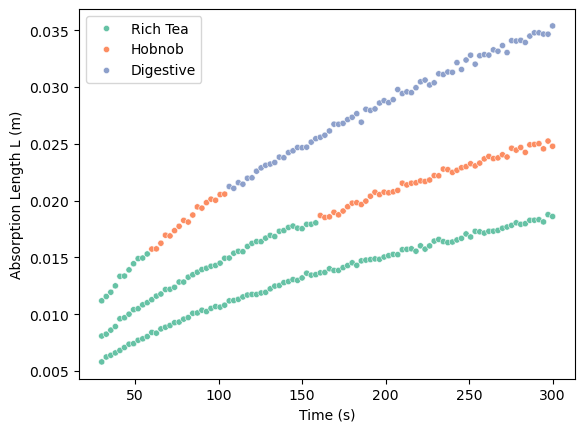

In [33]:
# Scale the tr data 
X_tr = StandardScaler().fit_transform(all_tr_biscuits)

# Predict the biscuit type for the tr data using the trained SVC model (optimised)
biscuit_pred_tr = trained_svc_optimised.predict(X_tr)

# Add predictions to the tr DataFrame (but make a new copy)
all_tr_biscuits_labelled = all_tr_biscuits.copy()
all_tr_biscuits_labelled['predicted_biscuit'] = biscuit_pred_tr

# Plot the data with colours mapped to the predicted biscuit type to assess the success of the model
# If successful, there should be one biscuit type per line
fig, ax = plt.subplots()
sns.scatterplot(data=all_tr_biscuits_labelled, x='t', y='L', hue='predicted_biscuit', palette='Set2', ax=ax, s=20)

# Format plot 
ax.set_xlabel("Time (s)")
ax.set_ylabel("Absorption Length L (m)")
ax.legend()
plt.show()

- Overall the trained SVC was unsuccessful in predicting the biscuit type of the time-resolved datasets as there is a lot of crossover between datasets
- It seems to successfully predict Rich Teas but not Hobnobs or Digestives.
- This may be because the original training dataset (dunking-data) only includes samples with time up to 30 seconds (whereas the time-resolved data goes up to 300 seconds)

**2. Adding Washburn-calculated Pore Radius to the Training Dataset (dunking-data) to try and Improve Classification Performance**

- As the Washburn equation performed very well at predicting pore radius in RQ 3 (RMSE = 1.19e-8, R-Squared = 0.997), it is justified to use it to estimate pore radius 'r' for the dunking-data set (training data).
- We can then use the pore radius as an additional input feature, and retrain the classification model.
- Hopefully this will improve performance, so that the time-resolved data can be successfully classified.

In [34]:
# Copy the dunking_df dataframe to avoid affecting the earlier analysis 
dunking_df_r = dunking_df.copy()

# Calculate r using Washburn equation and add it to the df as an additional input feature
dunking_df_r['r'] = washburn_r(dunking_df_r)
dunking_df_r

,gamma,phi,eta,L,t,biscuit,r
0,0.073897,1.333006,0.000999,0.011196,19.362214,Digestive,7.429094e-07
1,0.080946,1.476758,0.001012,0.005894,11.852589,Digestive,7.803690e-07
2,0.087408,1.477141,0.000984,0.009249,24.793669,Digestive,8.302559e-07
3,0.070793,1.502001,0.001002,0.003774,16.292780,Hobnob,3.598074e-07
4,0.058917,1.548274,0.001004,0.002291,13.662271,Hobnob,5.814437e-07
...,...,...,...,...,...,...,...
2995,0.084596,1.557367,0.000981,0.003221,24.231107,Digestive,7.396247e-07
2996,0.067928,1.487239,0.000993,0.003933,12.256570,Hobnob,4.421999e-07
2997,0.059526,1.444489,0.000998,0.007583,26.464108,Hobnob,5.781880e-07
2998,0.071386,1.212213,0.001004,0.013988,22.772293,Digestive,6.883535e-07


**Retraining the Support Vector Classification (SVC) model with the new training data:**

In [35]:
# Separate the features from the target variable
X_new = dunking_df_r.drop(columns=['biscuit'])
y_new = dunking_df_r['biscuit']

# Preprocess the data (split train-test and scale)
X_new_train, X_new_test, y_new_train, y_new_test = preprocessing(X_new, y_new, test_size=0.2, stratify=True, scaling=True)
print(f"X shape: {X_new_train.shape, X_new_test.shape}")
print(f"y shape: {y_new_train.shape, y_new_test.shape}")

# Train SVC on new data and evaluate its performance 
new_trained_svc = train_SVM_model(X_new_train, y_new_train, task="classification", optimise_model=True)
new_svc_accuracy = classifier_evaluation(new_trained_svc, X_new_train, X_new_test, y_new_train, y_new_test, "NEW SVC with Pore Radius")

X shape: ((2400, 6), (600, 6))
y shape: ((2400,), (600,))
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Optimal parameters found: {'C': 100, 'coef0': 0.0, 'degree': 3, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation score: 0.95

Evaluation Metrics for NEW SVC with Pore Radius:

Accuracy on the training data: 95.3% 
Accuracy on the testing data: 95.5% 
              precision    recall  f1-score   support

   Digestive       0.98      1.00      0.99       200
      Hobnob       0.96      0.91      0.93       200
    Rich Tea       0.93      0.96      0.95       200

    accuracy                           0.95       600
   macro avg       0.96      0.96      0.95       600
weighted avg       0.96      0.95      0.95       600



/Users/elliotayliffe/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


- Including the Washburn-calculated pore radius 'r' in the training data as an additional feature has improved classification performance.
- Accuracy has increased from **93.0%** (see RQ1) **to 95.5%**
- Lets check how important the pore radius feature is to the predictions using permutation importance  

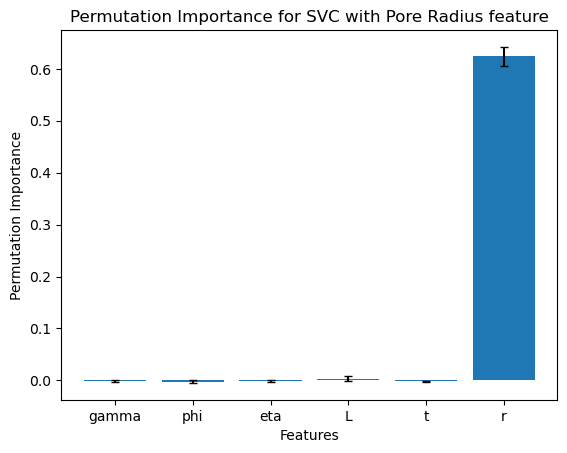

In [36]:
# Compute and plot permutation importance 
perm_importances = permutation_importance(new_trained_svc, X_new_test, y_new_test, n_repeats=30, random_state=18)
features = X_new.columns        # get the feature names 
fig, ax = plt.subplots()
ax.bar(np.arange(len(features)), perm_importances.importances_mean, yerr=perm_importances.importances_std, capsize=3)

# Format plot 
ax.set_title("Permutation Importance for SVC with Pore Radius feature")
ax.set_xticks(np.arange(len(features)))
ax.set_xticklabels(features)
ax.set_xlabel("Features")
ax.set_ylabel("Permutation Importance")
plt.show()

- The new SVC model almost **entirely relies on pore radius** when making predictions of the biscuit type, causing the other features to have no importance (making them redundant). 
- This suggests a very **strong correlation** between pore radius and biscuit type (as shown in Task 2). 
- Biscuit type can be almost fully determined by pore radius alone.

**3. Predicting the biscuit type for the time-resolved datasets using the new SVC model (trained with an additional pore radius feature)**

- First we calculate the pore radius for the time-resolved data using the Washburn Equation
- Then we predict the biscuit type using the newly trained model 

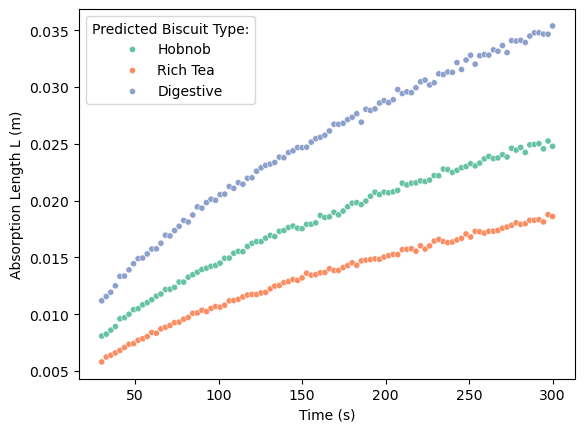

In [37]:
# Copy the all_tr_biscuits dataframe to avoid affecting the earlier analysis 
all_tr_biscuits_r = all_tr_biscuits.copy()

# Calculate r using Washburn equation and add it to the df
all_tr_biscuits_r['r'] = washburn_r(all_tr_biscuits_r)

X_tr_r = StandardScaler().fit_transform(all_tr_biscuits_r)
biscuit_pred_tr_r = new_trained_svc.predict(X_tr_r)       # Make predictions using new model 

# Add predictions to the tr DataFrame (but make a new copy)
all_tr_biscuits_r_labelled = all_tr_biscuits_r.copy()
all_tr_biscuits_r_labelled['predicted_biscuit'] = biscuit_pred_tr_r

# Plot the data with colours mapped to the predicted biscuit type to assess the success of the model
# If successful, there should be one biscuit type per line
fig, ax = plt.subplots()

sns.scatterplot(data=all_tr_biscuits_r_labelled, x='t', y='L', hue='predicted_biscuit', palette='Set2', ax=ax, s=20)

# Format plot 
ax.set_xlabel("Time (s)")
ax.set_ylabel("Absorption Length L (m)")
ax.legend(title='Predicted Biscuit Type:')
plt.show()

- The SVC model trained on the new dataset containing the Washburn-derived pore radius, was able to successfully identify which biscuit type was used for each tr dataset.

- Biscuit 1 (tr-1) = Hobnob 
- Biscuit 2 (tr-2) = Rich Tea
- Biscuit 3 (tr-3) = Digestive




<div style="color:purple">

### **Task 4 Findings:**

- The original trained SVC model was unable to successfully predict the biscuit type used in each time-resolved dataset.

- Retraining the classification model with Washburn-calculated pore radius as an additional feature improved its accuracy from **93.0% to 95.5%**.

- Permutation importances show that this new model is making predictions almost entirely based on the pore radius feature. This suggests a dominant correlation between pore radius and biscuit type (as we saw in Task 2).

- By calculating the pore radius for the tr datasets, the new classification model was able to successfully predict the biscuit type used in each tr dataset.

- This demonstrates that combining ML with traditional physics equations is an effective method.

<div style="color:purple">

### **Task 5.** 

### **Additional Analysis:** Assessing the Relationships between Absorption Length and Other Variables using ML Regression and Pearson Correlation

**Research Questions:**

- Which feature has the largest impact on absorption length L? (which is most strongly correlated?)

**Analysis Approach:**

1. Training a Random Forest regressor on the dunking dataset (with r), predict absorption length L, visualise the **feature importance** scores 

    - Features with higher importance scores may have a stronger influence on L

2. Compute the **Pearson correlation coefficients** to assess the relationships between variables and absorption length L (Higher positive or negative values indicate a stronger relationship)

    - Are these results consistent with the feature importance scores?


**Method 1. RF Regression - Feature Importance**

In [38]:
# Separate the features from the target variable
XL = dunking_df_r.drop(columns=['biscuit', 'L']) # Drop the biscuit type feature and 'L'
yL = dunking_df_r['L']                           # set target to L 

# Preprocess the data (split train-test and scale)
XL_train, XL_test, yL_train, yL_test = preprocessing(XL, yL, test_size=0.2, stratify=False, scaling=True)       # set stratify to false as it is not needed for regression
print(f"X shape: {XL_train.shape, XL_test.shape}")
print(f"y shape: {yL_train.shape, yL_test.shape}")

X shape: ((2400, 5), (600, 5))
y shape: ((2400,), (600,))


In [39]:
# Train Random Forest Regressor (with hyperparameter tuning)
trained_rf_reg_L = train_random_forest_model(XL_train, yL_train, task='regression', optimise_model=True)      # set task to regression 

# Display performance metrics
rf_reg_rmse_L, rf_reg_r2_L, rf_pred_LL = regressor_evaluation(trained_rf_reg_L, XL_train, XL_test, yL_train, yL_test, "Random Forest Regressor on dunking-data")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Optimal parameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score: -0.00

Evaluation Metrics for Random Forest Regressor on dunking-data:

RMSE on the training data: 1.37e-04
R² on the training data: 0.9982

RMSE on the testing data: 4.01e-04
R² on the testing data: 0.9841


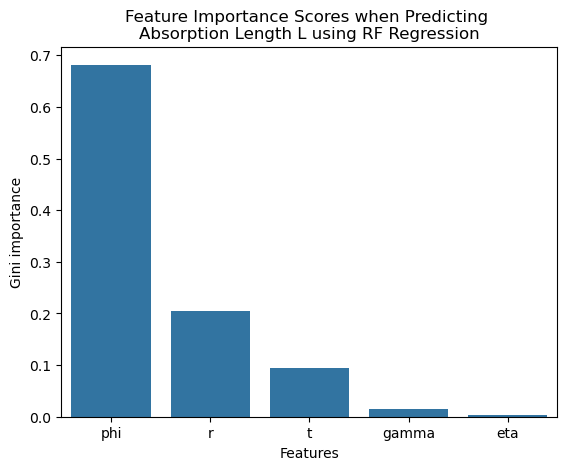

In [40]:
# Retrieve the feature importance scores (gini importance) and format as a pandas series 
gini_importances = trained_rf_reg_L.feature_importances_
gini_importances = pd.Series(gini_importances, index=XL.columns).sort_values(ascending=False)
gini_importances

# Plot feature importance scores 
fig, ax = plt.subplots()
sns.barplot(x=gini_importances.index, y=gini_importances.values)
ax.set_xlabel("Features")
ax.set_ylabel("Gini importance")
ax.set_title(f"Feature Importance Scores when Predicting \nAbsorption Length L using RF Regression")
plt.show()


<div style="color:purple">

- Gini importance is measure of how much a feature contributes to reducing impurity across all trees in a RF. A higher gini importance means the feature contributes more to node-splitting and has stronger influence when predicting absorption length. 

- These results suggest contact angle (phi) is strongly associated with L as the model relies on it the most, with pore radius (r) and time following.

- Tea viscosity and surface tension are least important, and hence are likely not strongly correlated.

- Lets see if these findings are consistent with pearson correlation coefficients 

**Method 2. Pearson Correlation**

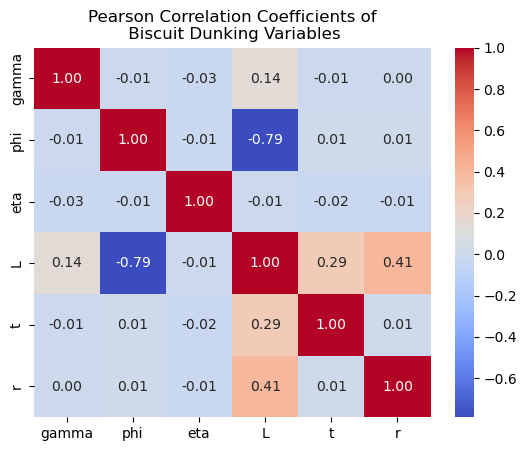

Correlation with Absorption Length (L):
L        1.000000
phi      0.789421
r        0.407657
t        0.286845
gamma    0.143117
eta      0.012111
Name: L, dtype: float64


In [41]:
# create dataframe with all variables except biscuit type 
corr_df = dunking_df_r.drop(columns=["biscuit"])

# Compute pearson correlation matrix 
corr_matrix = corr_df.corr()

# Plot matrix as heatmap 
fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
ax.set_title(f"Pearson Correlation Coefficients of\n Biscuit Dunking Variables")
plt.show()

# Print the ranking of strength of correlation with L 
print("Correlation with Absorption Length (L):")
print(corr_matrix["L"].abs().sort_values(ascending=False))

<div style="color:purple">

- Pearson correlation coefficients measure the linear relationships between two variables

- Contact angle has the strongest relationship with absorption length, followed by pore radius, then time.

- This is consistent with the order of feature importance from the Random Forest Regression method.

<div style="color:purple">

### **Task 5 Findings:**

- Both methods indicate that contact angle (phi) has the strongest relationship (negative correlation) with absorption length (L) and hence likely has the largest impact.

    - As contact angle increases, absorption length decreases.

- Pore radius and time are also slightly correlated with absorption length, whereas tea surface tension and viscosity are very weakly correlated and do not have significant impact on L.
